In [1]:
import pywt
import numpy as np
import pandas as pd
import os

In [2]:
os.chdir('..')

In [7]:
df = pd.read_csv('data/BTCUSD_2023_2024.csv', index_col='Gmt time')
df = df[-4050:]

In [12]:
close = df['Close']

In [25]:
coeff1 = pywt.wavedec(close, 'db4', level=4)

In [20]:
close_pad = np.pad(close, pad_width=100, mode='edge')

In [23]:
coeff2 = pywt.wavedec(close_pad, 'db4', level=4)

In [28]:
coeff2[0].shape

(272,)

In [29]:
coeff1[0].shape

(259,)

In [26]:
if coeff1==coeff2:
    print('Equality')
else:
    print('No equality')

ValueError: operands could not be broadcast together with shapes (259,) (272,) 

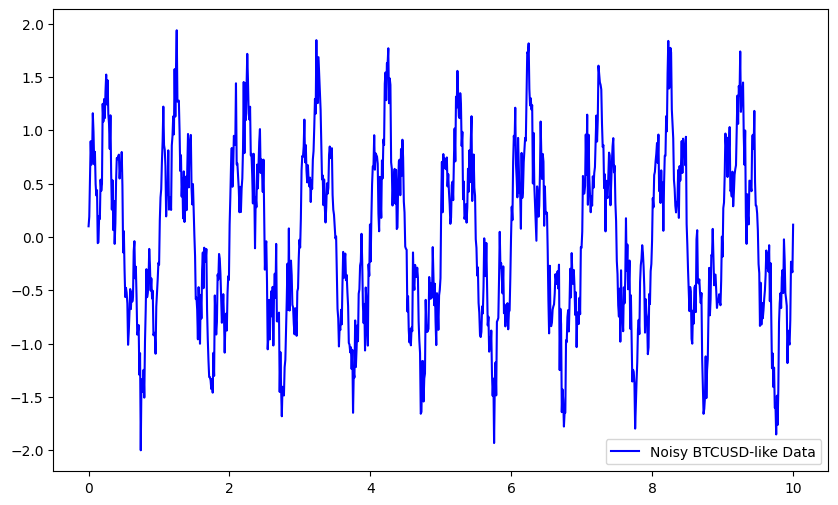

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic BTCUSD-like data
np.random.seed(42)
t = np.linspace(0, 10, 1000)
signal = np.sin(2 * np.pi * t) + 0.5 * np.sin(10 * np.pi * t)  # Smooth trend + high-frequency component
noise = 0.2 * np.random.randn(1000)  # Add Gaussian noise
data = signal + noise

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(t, data, label="Noisy BTCUSD-like Data", color='blue')
plt.legend()
plt.show()

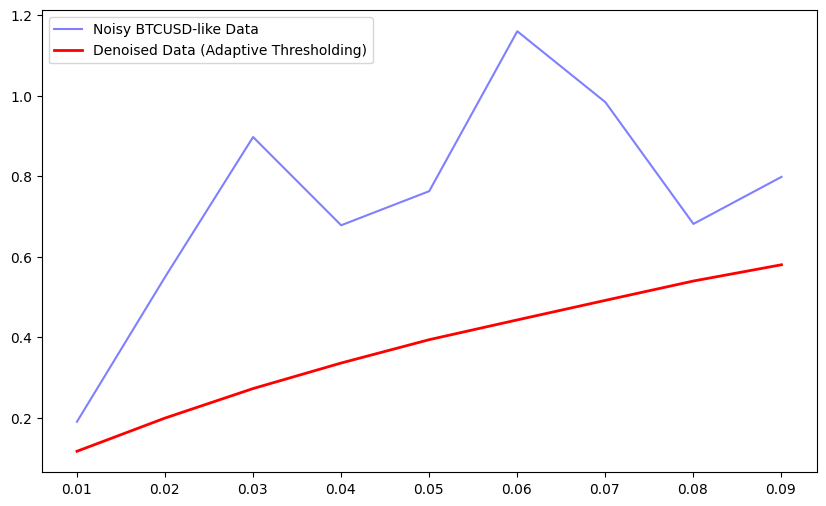

In [70]:
import pywt

def adaptive_thresholding(data, wavelet='db4', level=4, threshold_mode='soft'):
    # Decompose signal using Wavelet Transform
    coeff = pywt.wavedec(data, wavelet, mode="per", level=level)
    
    # Estimate the noise level
    sigma = (1 / 0.6745) * np.median(np.abs(coeff[-level] - np.median(coeff[-level])))
    
    # Calculate level-dependent thresholds
    thresholds = [sigma * np.sqrt(2 * np.log(len(data))) / (2 ** (i + 1)) for i in range(level)]
    
    # Apply thresholding to detail coefficients
    coeff[1:] = [pywt.threshold(i, value=thresh, mode=threshold_mode) for i, thresh in zip(coeff[1:], thresholds)]
    
    # Reconstruct the denoised signal
    denoised_data = pywt.waverec(coeff, wavelet, mode='per')
    
    return denoised_data

# Apply adaptive thresholding
denoised_data = adaptive_thresholding(data)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(t[1:10], data[1:10], label="Noisy BTCUSD-like Data", color='blue', alpha=0.5)
plt.plot(t[1:10], denoised_data[1:10], label="Denoised Data (Adaptive Thresholding)", color='red', linewidth=2)
plt.legend()
plt.show()

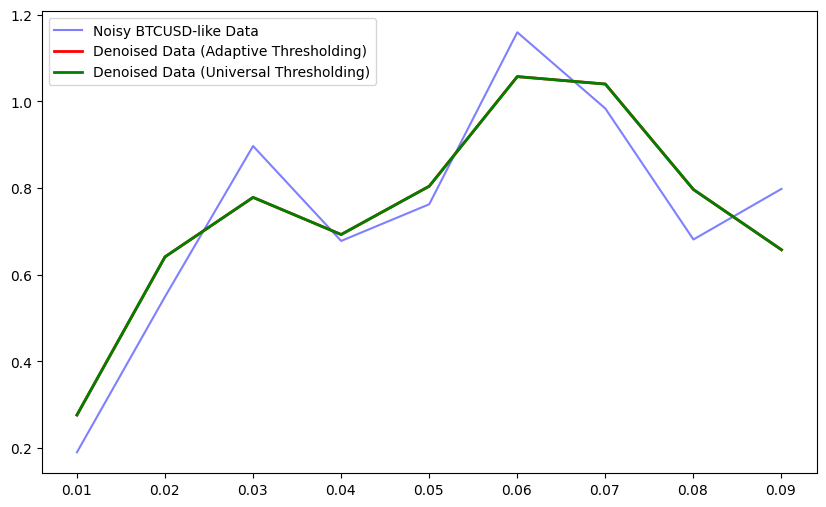

In [69]:
def universal_thresholding(data, wavelet='db4', level=1, threshold_mode='hard'):
    # Decompose signal using Wavelet Transform
    coeff = pywt.wavedec(data, wavelet, mode="per", level=level)
    
    # Estimate the noise level
    sigma = (1 / 0.6745) * np.median(np.abs(coeff[-level] - np.median(coeff[-level])))
    
    # Calculate the universal threshold
    uthresh = sigma * np.sqrt(2 * np.log(len(data)))
    
    # Apply thresholding to detail coefficients
    coeff[1:] = [pywt.threshold(i, value=uthresh, mode=threshold_mode) for i in coeff[1:]]
    
    # Reconstruct the denoised signal
    denoised_data = pywt.waverec(coeff, wavelet, mode='per')
    
    return denoised_data

# Apply universal thresholding
denoised_data_universal = universal_thresholding(data)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(t[1:10], data[1:10], label="Noisy BTCUSD-like Data", color='blue', alpha=0.5)
plt.plot(t[1:10], denoised_data[1:10], label="Denoised Data (Adaptive Thresholding)", color='red', linewidth=2)
plt.plot(t[1:10], denoised_data_universal[1:10], label="Denoised Data (Universal Thresholding)", color='green', linewidth=2)
plt.legend()
plt.show()